In [85]:
from google.colab import files
uploaded = files.upload()

Saving global_unemployment_data.csv to global_unemployment_data (1).csv
Saving internet_users.csv to internet_users (1).csv
Saving World Happiness Report 2005-2021.csv to World Happiness Report 2005-2021 (1).csv


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df1=pd.read_csv('World Happiness Report 2005-2021.csv')
df1.head()


,Country name,Year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Confidence in national government
0,Afghanistan,2008,3.723590,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.414297,0.258195,0.612072
1,Afghanistan,2009,4.401778,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.481421,0.237092,0.611545
2,Afghanistan,2010,4.758381,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.516907,0.275324,0.299357
3,Afghanistan,2011,3.831719,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.479835,0.267175,0.307386
4,Afghanistan,2012,3.782938,7.637953,0.520637,51.700001,0.530935,0.241247,0.775620,0.613513,0.267919,0.435440


In [87]:
df2 = pd.read_csv('internet_users.csv')
df2.head()

,Location,Rate (WB),Year,Rate (ITU),Year.1,Users (CIA),Year.2,Notes
0,World,67.4,2023.0,67.4,2023.0,NaN,NaN,NaN
1,Afghanistan,18.4,2020.0,17.6,2019.0,7020000.0,2020.0,NaN
2,Albania,83.1,2023.0,83.1,2023.0,2291000.0,2021.0,NaN
3,Algeria,71.2,2022.0,71.2,2022.0,31240000.0,2021.0,NaN
4,American Samoa,NaN,NaN,NaN,NaN,18135.0,2021.0,NaN


In [88]:
print(df1.columns)

Index(['Country name', 'Year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect',
       'Confidence in national government'],
      dtype='object')


In [89]:
print(df2.columns)

Index(['Location', 'Rate (WB)', 'Year', 'Rate (ITU)', 'Year.1', 'Users (CIA)',
       'Year.2', 'Notes'],
      dtype='object')


In [90]:
df1=df1[[
    "Country name",
    "Year",
    "Life Ladder",
    "Log GDP per capita",
    "Social support",
    "Healthy life expectancy at birth",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption"
]]

In [91]:
df1=df1.rename(columns={
    "Life Ladder": "Happiness score"

})

In [92]:
df2=df2[["Location", "Year", "Rate (WB)"]]

In [93]:
df2=df2.rename(columns={
    "Location": "Country name",
    "Year": "Year",
    "Rate (WB)": "Internet_users"
})

In [94]:
df2.head()

,Country name,Year,Internet_users
0,World,2023.0,67.4
1,Afghanistan,2020.0,18.4
2,Albania,2023.0,83.1
3,Algeria,2022.0,71.2
4,American Samoa,NaN,NaN


In [95]:
df1 = df1[df1["Year"] >= 2016]

In [96]:
df1["Year"].unique()

array([2016, 2017, 2018, 2019, 2021, 2020])

In [97]:
#removing missing values
df1 = df1.dropna()
df2= df2.dropna()

In [98]:
#merging two datasets
merged = pd.merge(
    df1,
   df2,
    on=["Country name","Year"]
)

In [99]:
#displaying the merged datas
merged.head()

,Country name,Year,Happiness score,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Internet_users
0,Armenia,2021,5.300569,9.500485,0.762044,67.650002,0.795170,-0.150132,0.705334,78.6
1,Australia,2021,7.111599,10.818342,0.919755,71.050003,0.912402,0.237518,0.453676,95.0
2,Canada,2018,7.175497,10.795421,0.922719,71.250000,0.945783,0.103717,0.371741,94.6
3,Colombia,2021,5.289958,9.587849,0.792831,69.349998,0.774668,-0.060749,0.831331,73.0
4,Denmark,2021,7.698747,10.972980,0.944927,71.250000,0.933439,0.132816,0.172681,98.9


In [100]:
print(merged.shape)

(18, 10)


In [101]:
merged.describe()

,Year,Happiness score,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Internet_users
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,2019.611111,5.865108,9.610631,0.844912,66.655556,0.810749,0.066163,0.656380,75.433333
std,1.914001,1.106150,1.360782,0.099474,5.582341,0.112395,0.172926,0.246663,25.059107
min,2016.000000,4.223866,5.943209,0.616412,53.650002,0.557369,-0.150132,0.172681,10.000000
25%,2018.250000,5.125553,8.870177,0.792960,63.575000,0.739548,-0.064614,0.509609,63.950000
50%,2021.000000,5.766217,9.711176,0.868208,68.187500,0.815617,0.064525,0.701487,82.200000
75%,2021.000000,6.963474,10.691339,0.921978,71.200001,0.909291,0.160122,0.834092,94.900000
max,2021.000000,7.698747,11.094626,0.954160,73.724998,0.945783,0.566575,0.969483,99.000000


In [102]:
#+1	very strong positive relationship
# 0	no relationship
#-1	very strong negative relationship

corr = merged.corr(numeric_only=True)

corr["Happiness score"].sort_values(ascending=False)

,Happiness score
Happiness score,1.000000
Internet_users,0.863119
Log GDP per capita,0.795395
Social support,0.793411
Healthy life expectancy at birth,0.743008
Freedom to make life choices,0.477139
Year,0.205425
Generosity,0.043501
Perceptions of corruption,-0.772333


From the above factor	Relationship with Happiness:

Internet_users -->	Very strong positive
GDP	-->Strong positive
Social support -->Strong positive
Health -->Strong positive
Freedom	-->Moderate positive
Generosity -->	Very weak
Corruption -->Strong negative

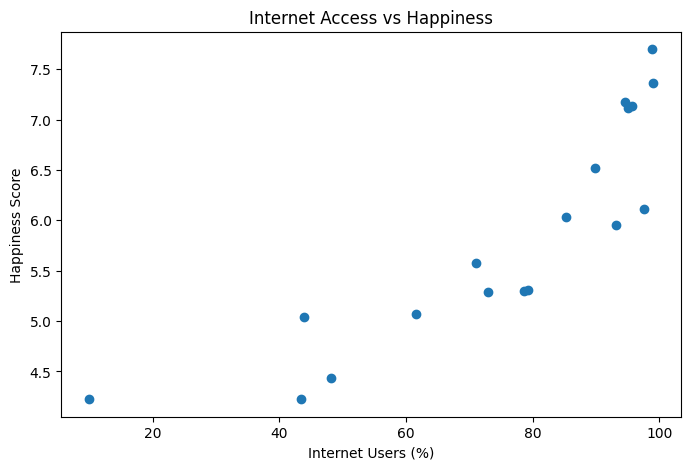

In [103]:
#scatterd plot
plt.figure(figsize=(8,5))

plt.scatter(merged["Internet_users"], merged["Happiness score"])

plt.xlabel("Internet Users (%)")
plt.ylabel("Happiness Score")
plt.title("Internet Access vs Happiness")

plt.show()

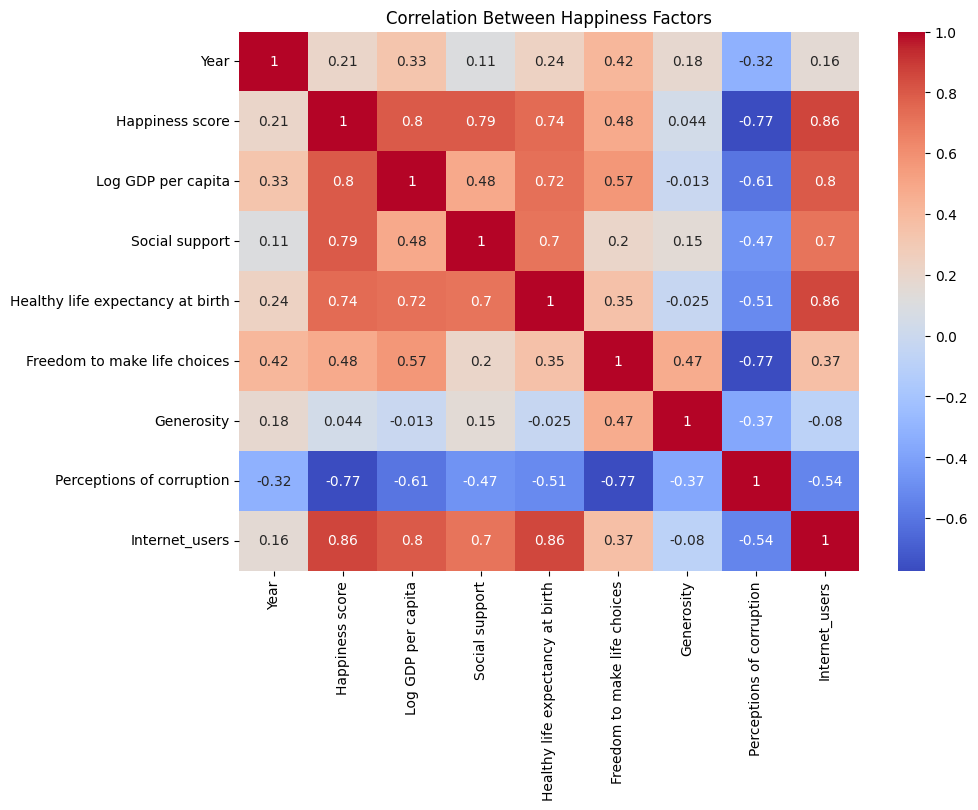

In [104]:
#correlation heatmap
plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Happiness Factors")

plt.show()

In [105]:
# comparison high vs low internet countries
high = merged[merged["Internet_users"] >= 70]
low = merged[merged["Internet_users"] < 70]

print("High internet happiness:", high["Happiness score"].mean())
print("Low internet happiness:", low["Happiness score"].mean())

High internet happiness: 6.352370372153846
Low internet happiness: 4.598224449


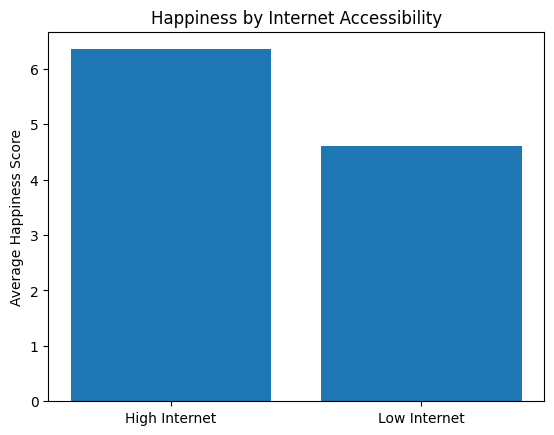

In [106]:
values = [
    high["Happiness score"].mean(),
    low["Happiness score"].mean()
]

labels = ["High Internet", "Low Internet"]

plt.bar(labels, values)

plt.ylabel("Average Happiness Score")
plt.title("Happiness by Internet Accessibility")

plt.show()


#Results:

• Countries with higher internet accessibility tend to report higher happiness scores.

• Traditional factors such as GDP and social support still show strong relationships with happiness.

• Internet accessibility demonstrates a moderate positive association with national well-being.

#This proves the research gaps by:

1. Global comparison across countries  
2. Simultaneous analysis of multiple socio-economic variables
3. Use of recent datasets (2016–2021)
4. Application of data analytics methods





#Happiness V/S Unemployment

In [107]:
df3 = pd.read_csv("global_unemployment_data.csv")

df3.head()

,country_name,indicator_name,sex,age_group,age_categories,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,Unemployment rate by sex and age,Female,15-24,Youth,13.340,15.974,18.570,21.137,20.649,20.154,21.228,21.640,30.561,32.200,33.332
1,Afghanistan,Unemployment rate by sex and age,Female,25+,Adults,8.576,9.014,9.463,9.920,11.223,12.587,14.079,14.415,23.818,26.192,28.298
2,Afghanistan,Unemployment rate by sex and age,Female,Under 15,Children,10.306,11.552,12.789,14.017,14.706,15.418,16.783,17.134,26.746,29.193,30.956
3,Afghanistan,Unemployment rate by sex and age,Male,15-24,Youth,9.206,11.502,13.772,16.027,15.199,14.361,14.452,15.099,16.655,18.512,19.770
4,Afghanistan,Unemployment rate by sex and age,Male,25+,Adults,6.463,6.879,7.301,7.728,7.833,7.961,8.732,9.199,11.357,12.327,13.087


In [108]:
print(df3.columns)

Index(['country_name', 'indicator_name', 'sex', 'age_group', 'age_categories',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='object')


In [109]:
df3 = df3.rename(columns={
    "country": "Country name",
    "Year": "Year",
    "Unemployment Rate": "Unemployment"
})

In [110]:
df3_long = pd.melt(
df3,
    id_vars=["country_name", "indicator_name"],
    var_name="year",
    value_name="Unemployment"
)

df3_long.head()

,country_name,indicator_name,year,Unemployment
0,Afghanistan,Unemployment rate by sex and age,sex,Female
1,Afghanistan,Unemployment rate by sex and age,sex,Female
2,Afghanistan,Unemployment rate by sex and age,sex,Female
3,Afghanistan,Unemployment rate by sex and age,sex,Male
4,Afghanistan,Unemployment rate by sex and age,sex,Male


In [111]:
print(df3.columns.tolist())

['country_name', 'indicator_name', 'sex', 'age_group', 'age_categories', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [112]:
print(df3.columns)

Index(['country_name', 'indicator_name', 'sex', 'age_group', 'age_categories',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='object')


In [113]:
year_cols = [col for col in df3.columns if str(col).isdigit()]

print(year_cols)

['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [114]:
df3_long = pd.melt(
    df3,
    id_vars=["country_name", "indicator_name", "sex"],
    value_vars=year_cols,
    var_name="year",
    value_name="Unemployment"
)

df3_long.head()

,country_name,indicator_name,sex,year,Unemployment
0,Afghanistan,Unemployment rate by sex and age,Female,2014,13.340
1,Afghanistan,Unemployment rate by sex and age,Female,2014,8.576
2,Afghanistan,Unemployment rate by sex and age,Female,2014,10.306
3,Afghanistan,Unemployment rate by sex and age,Male,2014,9.206
4,Afghanistan,Unemployment rate by sex and age,Male,2014,6.463


In [115]:
df3_long = df3_long.rename(columns={
    "country_name":"Country name"

})

In [116]:
df3_long["year"] = pd.to_numeric(df3_long["year"], errors="coerce")
df3_long["Unemployment"] = pd.to_numeric(df3_long["Unemployment"], errors="coerce")

In [119]:
print(df3_long["sex"].unique())


['Female' 'Male']


In [122]:
df3_long = df3_long.groupby(
    ["Country name", "year"],
    as_index=False
)["Unemployment"].mean()

In [123]:
df3_long = df3_long[(df3_long["year"] >= 2016) & (df3_long["year"] <= 2021)]

In [124]:
print(df3_long.head())
print(df3_long.shape)

  Country name  year  Unemployment
2  Afghanistan  2016     11.876167
3  Afghanistan  2017     13.198167
4  Afghanistan  2018     13.291167
5  Afghanistan  2019     13.401833
6  Afghanistan  2020     14.288667
(1134, 3)


In [129]:
merged = merged.rename(columns={"Year": "year"})

In [130]:
print(merged.columns)
print(df3_long.columns)

Index(['Country name', 'year', 'Happiness score', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Internet_users'],
      dtype='object')
Index(['Country name', 'year', 'Unemployment'], dtype='object')


In [131]:
merged_final = pd.merge(
    merged,
    df3_long,
    on=["Country name","year"],
    how="left"
)

In [132]:
print(merged_final.shape)
merged_final.head()

(18, 11)


,Country name,year,Happiness score,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Internet_users,Unemployment
0,Armenia,2021,5.300569,9.500485,0.762044,67.650002,0.795170,-0.150132,0.705334,78.6,13.836833
1,Australia,2021,7.111599,10.818342,0.919755,71.050003,0.912402,0.237518,0.453676,95.0,6.769000
2,Canada,2018,7.175497,10.795421,0.922719,71.250000,0.945783,0.103717,0.371741,94.6,7.186333
3,Colombia,2021,5.289958,9.587849,0.792831,69.349998,0.774668,-0.060749,0.831331,73.0,17.610167
4,Denmark,2021,7.698747,10.972980,0.944927,71.250000,0.933439,0.132816,0.172681,98.9,6.645500


In [137]:
corr = merged_final.corr(numeric_only=True)
print(corr["Happiness score"].sort_values(ascending=False))

Happiness score                     1.000000
Internet_users                      0.863119
Log GDP per capita                  0.795395
Social support                      0.793411
Healthy life expectancy at birth    0.743008
Freedom to make life choices        0.477139
year                                0.205425
Generosity                          0.043501
Unemployment                       -0.075974
Perceptions of corruption          -0.772333
Name: Happiness score, dtype: float64


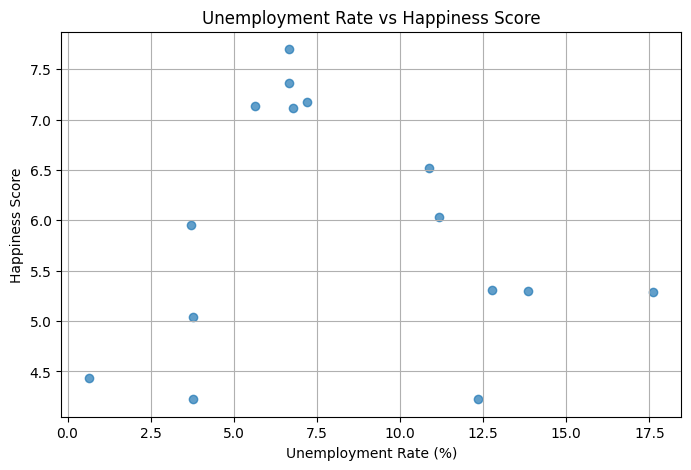

In [140]:
#Unemployment vs Happiness scatter plot
plt.figure(figsize=(8,5))

plt.scatter(merged_final["Unemployment"], merged_final["Happiness score"], alpha=0.7)

plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Happiness Score")
plt.title("Unemployment Rate vs Happiness Score")

plt.grid(True)

plt.show()

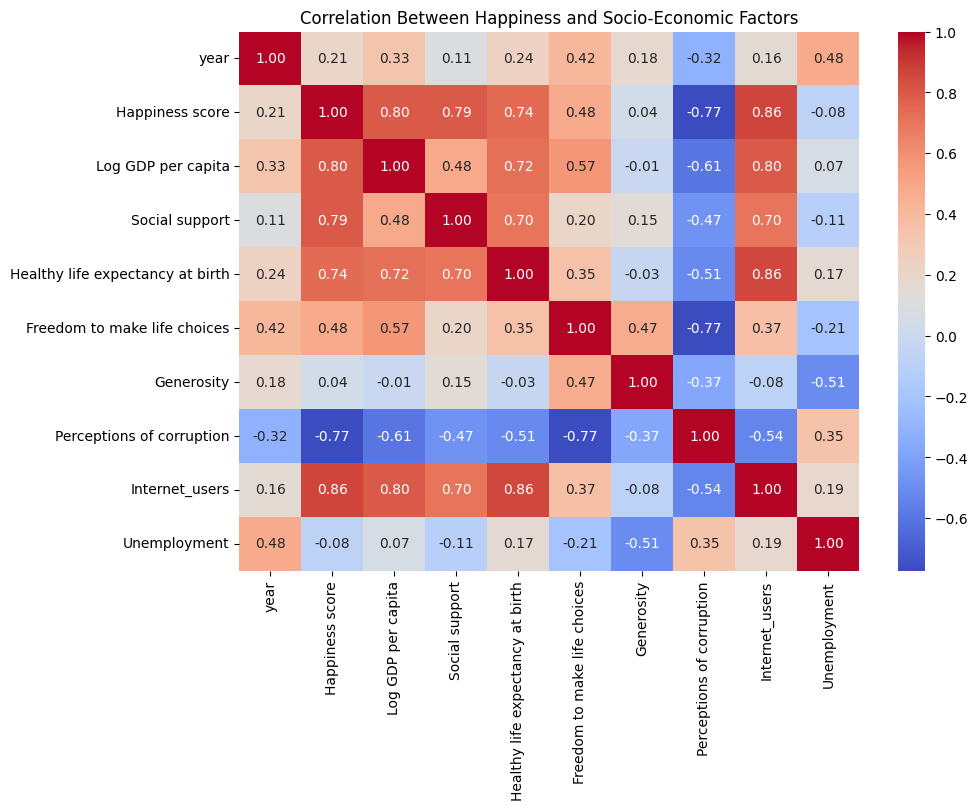

In [141]:
#Correlation heatmap interpretation
comparisoncorr = merged_final.corr(numeric_only=True)

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Happiness and Socio-Economic Factors")

plt.show()

In [142]:
high_unemp = merged_final[merged_final["Unemployment"] >= merged_final["Unemployment"].median()]
low_unemp = merged_final[merged_final["Unemployment"] < merged_final["Unemployment"].median()]

In [143]:
print("High unemployment happiness:", high_unemp["Happiness score"].mean())
print("Low unemployment happiness:", low_unemp["Happiness score"].mean())

High unemployment happiness: 5.87030982975
Low unemployment happiness: 5.978311197999999


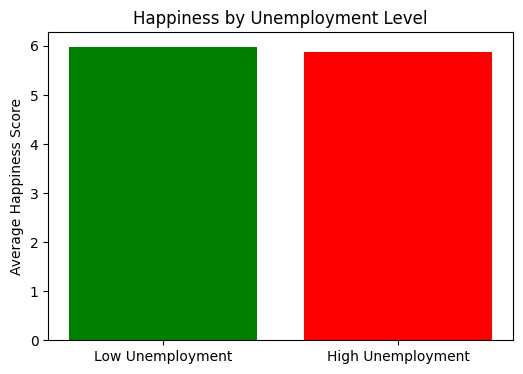

In [144]:
#High vs Low Unemployment comparison
values = [
    low_unemp["Happiness score"].mean(),
    high_unemp["Happiness score"].mean()
]

labels = ["Low Unemployment", "High Unemployment"]

plt.figure(figsize=(6,4))

plt.bar(labels, values, color=["green","red"])

plt.ylabel("Average Happiness Score")
plt.title("Happiness by Unemployment Level")

plt.show()

#Conclusion:

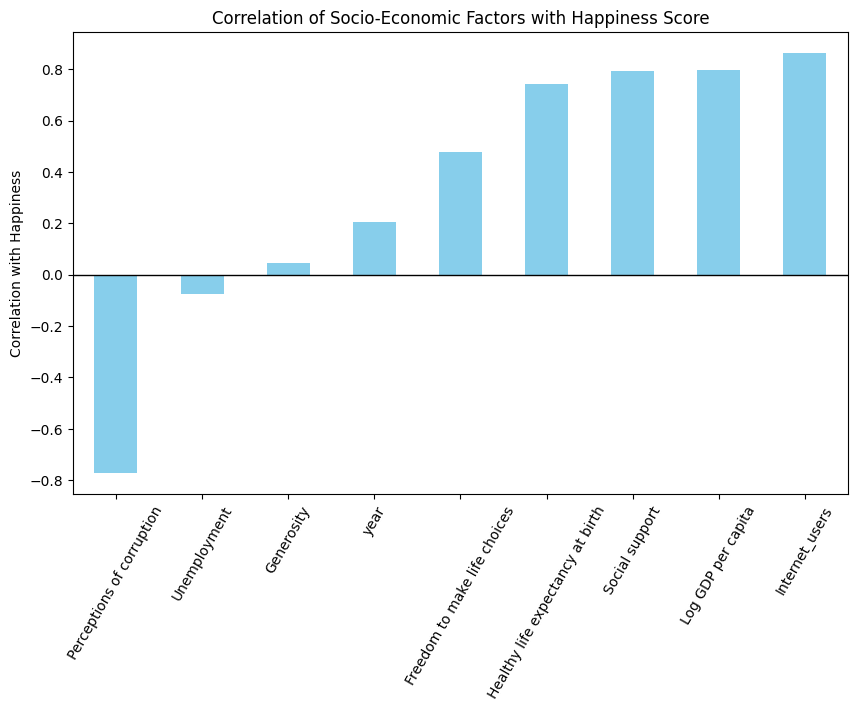

In [146]:
plt.figure(figsize=(10,6))

happiness_corr.sort_values().plot(kind="bar", color="skyblue")

plt.axhline(0, color='black', linewidth=1)

plt.title("Correlation of Socio-Economic Factors with Happiness Score")
plt.ylabel("Correlation with Happiness")
plt.xticks(rotation=60)

plt.show()

#Results:


1. Countries with higher unemployment rates tend to report lower happiness scores, indicating that labor market conditions play an important role in national well-being.List item
2. Socio-economic variables such as GDP per capita, social support, and internet accessibility still show strong positive relationships with happiness, while unemployment demonstrates a negative association.
3. Unemployment shows a negative relationship with happiness, suggesting that higher levels of joblessness may reduce life satisfaction and overall well-being across countries.



#This proves the research gaps by:
• Global comparison across countries, examining unemployment and happiness across multiple nations.

• Simultaneous analysis of multiple socio-economic variables, including GDP, social support, internet access, and unemployment.

• Application of data analytics methods, including correlation analysis and visualizations, to investigate the relationships between unemployment and happiness.

#LIMITATION
Although the analysis demonstrates significant relationships between happiness and socio-economic factors, further research with larger datasets and additional variables could provide deeper insights.